Shape: (768, 9)
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Class distribution (Outcome):
Outcome
0    500
1    268
Name: count, dtype: int64

Train shape: (614, 8) | Test shape: (154, 8)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,689 (10.50 KB)

 Trainable params: 2,689 (10.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.5036 - loss: 0.7044 - val_accuracy: 0.6613 - val_loss: 0.6355
Epoch 2/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7101 - loss: 0.5947 - val_accuracy: 0.7097 - val_loss: 0.5573
Epoch 3/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7681 - loss: 0.5378 - val_accuracy: 0.7419 - val_loss: 0.5114
Epoch 4/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7862 - loss: 0.5007 - val_accuracy: 0.7419 - val_loss: 0.4861
Epoch 5/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7862 - loss: 0.4775 - val_accuracy: 0.7581 - val_loss: 0.4730
Epoch 6/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7917 - loss: 0.4635 - val_accuracy: 0.7581 - val_loss: 0.4663
Epoch 7/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8025 - loss: 0.4543 - val_accuracy: 0.7581 - val_loss: 0.4627
Epoch 8/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8043 - loss: 0.4478 - val_accuracy: 0.7581 - 

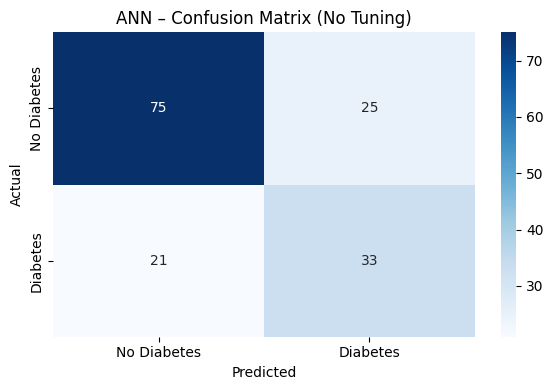

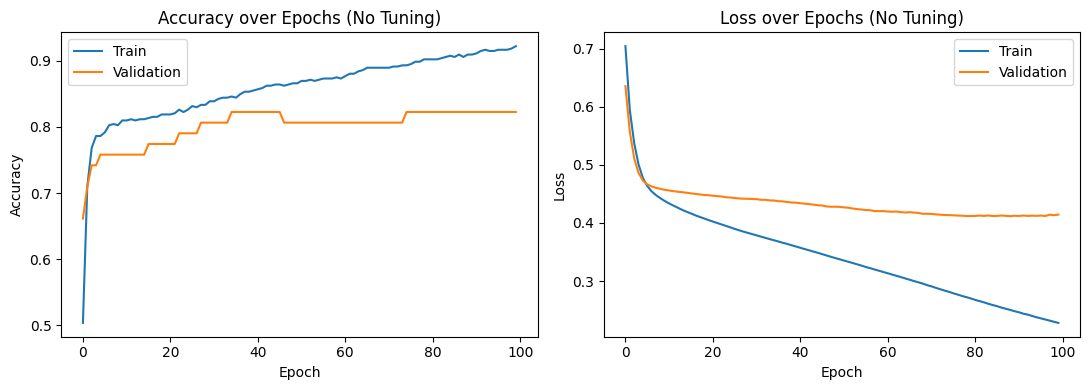


Architecture: Input(8) → Dense(64,relu) → Dense(32,relu) → Dense(1,sigmoid)
Optimizer: Adam(lr=0.001) | Epochs: 100 | Batch Size: 32


In [1]:
# Artificial Neural Network – Without Hyperparameter Tuning
# Dataset: Pima Indians Diabetes (diabetes.csv)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.random.set_seed(42)
np.random.seed(42)

# Load dataset
df = pd.read_csv("diabetes.csv")
print("Shape:", df.shape)
print(df.head())
print("\nClass distribution (Outcome):")
print(df["Outcome"].value_counts())

# Features and target
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

# Train-test split (80/20, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("\nTrain shape:", X_train.shape, "| Test shape:", X_test.shape)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Baseline ANN: Input(8) → Dense(64,relu) → Dense(32,relu) → Dense(1,sigmoid)
model = keras.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(1,  activation='sigmoid')
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

# Train
history = model.fit(
    X_train_scaled, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

# Evaluate
y_pred_prob = model.predict(X_test_scaled).flatten()
y_pred = (y_pred_prob >= 0.5).astype(int)

acc = accuracy_score(y_test, y_pred)
print("\n========== ANN (No Tuning) ==========")
print(f"Accuracy: {acc * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred,
      target_names=["No Diabetes", "Diabetes"]))
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# Confusion matrix plot
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["No Diabetes", "Diabetes"],
            yticklabels=["No Diabetes", "Diabetes"])
plt.title("ANN – Confusion Matrix (No Tuning)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# Training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(history.history['accuracy'],     label='Train')
ax1.plot(history.history['val_accuracy'], label='Validation')
ax1.set_title('Accuracy over Epochs (No Tuning)')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax2.plot(history.history['loss'],     label='Train')
ax2.plot(history.history['val_loss'], label='Validation')
ax2.set_title('Loss over Epochs (No Tuning)')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
plt.tight_layout()
plt.show()

print("\nArchitecture: Input(8) → Dense(64,relu) → Dense(32,relu) → Dense(1,sigmoid)")
print("Optimizer: Adam(lr=0.001) | Epochs: 100 | Batch Size: 32")


Starting hyperparameter search (20 trials)...
Search complete.

========== Best Hyperparameters Found ==========
num_layers    : 2
units_0      : 128
dropout_0    : 0.2
units_1      : 32
dropout_1    : 0.0
learning_rate : 0.005
Epoch 1/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.6812 - loss: 0.5814 - val_accuracy: 0.7581 - val_loss: 0.4367
Epoch 2/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7736 - loss: 0.4766 - val_accuracy: 0.7742 - val_loss: 0.4350
Epoch 3/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7935 - loss: 0.4477 - val_accuracy: 0.7742 - val_loss: 0.4271
Epoch 4/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7935 - loss: 0.4466 - val_accuracy: 0.7742 - val_loss: 0.4447
Epoch 5/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8007 - loss: 0.4328 - val_accuracy: 0.7581 - val_loss: 0.4570
Epoch 6/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7844 - loss: 0.4329 - val_accuracy: 0.7742 - val_loss: 0.4407
Epoch 7/1

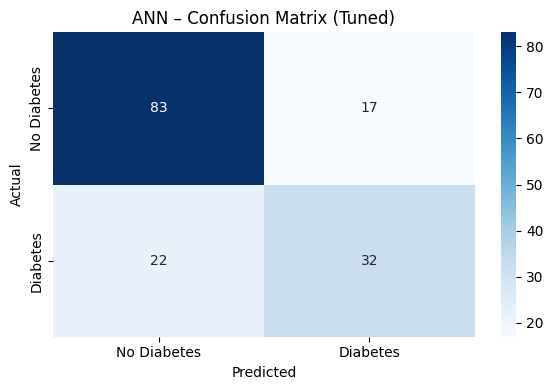

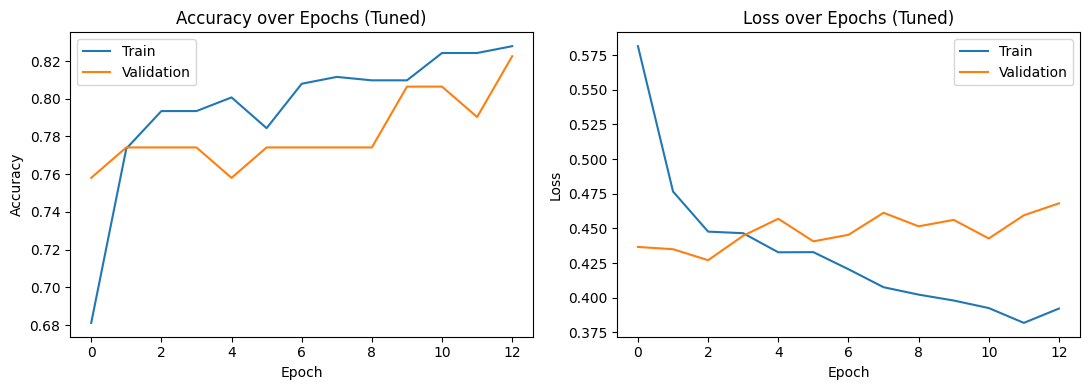

In [5]:
# Artificial Neural Network – With Hyperparameter Tuning (Keras Tuner)
# Dataset: Pima Indians Diabetes (diabetes.csv)
!pip install keras-tuner
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import keras_tuner as kt

tf.random.set_seed(42)
np.random.seed(42)

# Load and preprocess (identical to baseline)
df = pd.read_csv("diabetes.csv")
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

n_features = X_train_scaled.shape[1]

# Model builder for Keras Tuner
def build_model(hp):
    model = keras.Sequential()
    model.add(layers.Input(shape=(n_features,)))

    for i in range(hp.Int('num_layers', 1, 3)):
        units = hp.Choice(f'units_{i}', [16, 32, 64, 128])
        model.add(layers.Dense(units, activation='relu'))
        drop = hp.Float(f'dropout_{i}', 0.0, 0.4, step=0.1)
        if drop > 0.0:
            model.add(layers.Dropout(drop))

    model.add(layers.Dense(1, activation='sigmoid'))

    lr = hp.Choice('learning_rate', [1e-4, 5e-4, 1e-3, 5e-3])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

# Keras Tuner — Random Search (20 trials)
tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=20,
    seed=42,
    directory='kt_diabetes',
    project_name='ann_tuning',
    overwrite=True
)

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=10, restore_best_weights=True
)

print("Starting hyperparameter search (20 trials)...")
tuner.search(
    X_train_scaled, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=0
)
print("Search complete.")

# Best hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print("\n========== Best Hyperparameters Found ==========")
n_layers = best_hps.get('num_layers')
print(f"num_layers    : {n_layers}")
for i in range(n_layers):
    print(f"units_{i}      : {best_hps.get(f'units_{i}')}")
    print(f"dropout_{i}    : {best_hps.get(f'dropout_{i}')}")
print(f"learning_rate : {best_hps.get('learning_rate')}")

# Train best model fully
best_model = tuner.hypermodel.build(best_hps)
history = best_model.fit(
    X_train_scaled, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)
print(f"\nTraining stopped at epoch: {len(history.history['accuracy'])}")

# Evaluate
y_pred_prob = best_model.predict(X_test_scaled).flatten()
y_pred = (y_pred_prob >= 0.5).astype(int)
acc = accuracy_score(y_test, y_pred)

print("\n========== ANN (With Tuning) ==========")
print(f"Accuracy: {acc * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred,
      target_names=["No Diabetes", "Diabetes"]))
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# Confusion matrix plot
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["No Diabetes", "Diabetes"],
            yticklabels=["No Diabetes", "Diabetes"])
plt.title("ANN – Confusion Matrix (Tuned)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# Training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(history.history['accuracy'],     label='Train')
ax1.plot(history.history['val_accuracy'], label='Validation')
ax1.set_title('Accuracy over Epochs (Tuned)')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax2.plot(history.history['loss'],     label='Train')
ax2.plot(history.history['val_loss'], label='Validation')
ax2.set_title('Loss over Epochs (Tuned)')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
plt.tight_layout()
plt.show()
